# Sample-Specific Variance in Differential Analysis

This tutorial demonstrates how to account for biological variability across samples in differential analysis. This is crucial when analyzing data from multiple biological replicates.

## Why Sample Variance Matters

When comparing conditions (e.g., treated vs. control), we typically have multiple biological replicates per condition. Biological variation **between samples** within the same condition is often larger than technical variation, and ignoring it can lead to:

- Inflated statistical significance
- High false positive rates
- Poor reproducibility across studies

Kompot's sample variance estimation:

✓ Builds separate estimators for each sample  
✓ Computes sample-to-sample covariance  
✓ Adjusts significance based on inter-sample variability  
✓ Produces more conservative and reproducible results  

## Dataset

We'll use bone marrow data from young and old mice, with 3 biological replicates per age group.

In [2]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import palantir
import pandas as pd
import scanpy as sc

import kompot

plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["image.cmap"] = "Spectral_r"

In [3]:
DATA_PATH = "../data/murine_bone_marrow_aging.h5ad"
SAMPLE_COLUMN = "Replicate"        # Sample/replicate identifiers
GROUPING_COLUMN = "Age"
CONDITIONS = ["Young", "Old"]
CELL_TYPE_COLUMN = "highres_celltype"
DIMENSIONALITY_REDUCTION = "DM_EigenVectors"
LAYER_FOR_EXPRESSION = "logged_counts"

## Load Data

In [4]:
adata = ad.read_h5ad(DATA_PATH)
palantir.utils.run_diffusion_maps(adata, pca_key="X_pca_harmony", n_components=40)
adata

AnnData object with n_obs × n_vars = 8090 × 16285
    obs: 'Compartment', 'Replicate', 'Age', 'Sample', 'Info', 'batch', 'doublet_score', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'leiden', 'phenograph', 'highres_celltype', 'midres_celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Age_colors', 'Compartment_colors', 'DMEigenValues', 'Info_colors', 'README', 'Replicate_colors', 'Sample_colors', 'batch_colors', 'draw_graph', 'highres_celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'midres_celltype_colors', 'neighbors', 'pca', 'phase_colors', 'umap', 'DM_EigenValues'
    obsm: 'AbCapture', 'DM_EigenVectors', 'HTO', 'X_draw_graph_fa', 'X_pca', 'X_pca_harmony', 'X_

### Examine Sample Structure

In [5]:
# Check sample distribution
sample_counts = adata.obs.groupby([GROUPING_COLUMN, SAMPLE_COLUMN]).size().unstack(fill_value=0)
print("Cells per sample:\n", sample_counts)

Cells per sample:
 Replicate     1     2     3
Age                        
Mid        1035  1022     0
Old        1057  1019  1040
Young       944  1007   966


/loc/scratch/35159533/ipykernel_27996/1340399861.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_counts = adata.obs.groupby([GROUPING_COLUMN, SAMPLE_COLUMN]).size().unstack(fill_value=0)


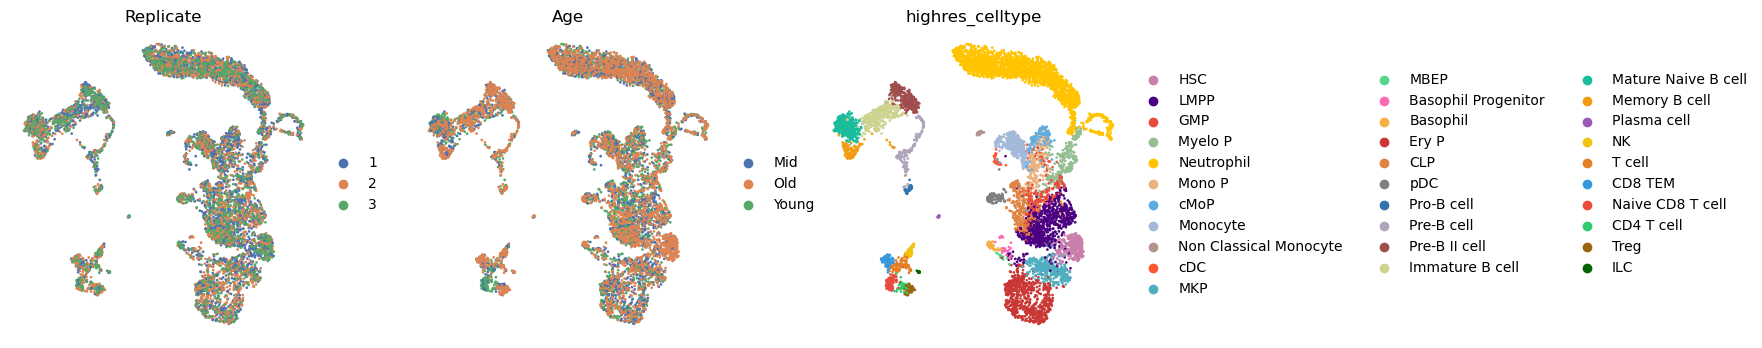

In [6]:
sc.pl.umap(adata, color=[SAMPLE_COLUMN, GROUPING_COLUMN, CELL_TYPE_COLUMN], wspace=.2, frameon=False)

## Standard Analysis (Without Sample Variance)

First, we'll run analyses **without** accounting for sample variance. This serves as a baseline for comparison.

### Differential Abundance

In [7]:
da_standard = kompot.compute_differential_abundance(
    adata,
    groupby=GROUPING_COLUMN,
    condition1=CONDITIONS[0],
    condition2=CONDITIONS[1],
    obsm_key=DIMENSIONALITY_REDUCTION,
)

[2025-10-03 13:22:53,906] [INFO    ] Condition 1 (Young): 2,917 cells
[2025-10-03 13:22:53,907] [INFO    ] Condition 2 (Old): 3,116 cells
[2025-10-03 13:22:53,910] [INFO    ] Fitting density estimator for condition 1...


[2025-10-03 13:24:01,899] [INFO    ] Fitting density estimator for condition 2...
[2025-10-03 13:24:36,888] [WARNING ] The normalization is only effective if the density was trained with d_method="fractal".
[2025-10-03 13:24:38,245] [WARNING ] The normalization is only effective if the density was trained with d_method="fractal".
[2025-10-03 13:24:48,611] [INFO    ] This run will have `run_id=0`.


### Differential Expression

In [8]:
de_standard = kompot.compute_differential_expression(
    adata,
    groupby=GROUPING_COLUMN,
    condition1=CONDITIONS[0],
    condition2=CONDITIONS[1],
    layer=LAYER_FOR_EXPRESSION,
    obsm_key=DIMENSIONALITY_REDUCTION,
    batch_size=0, # No batching for this small dataset
)

[2025-10-03 13:24:51,212] [INFO    ] Condition 1 (Young): 2,917 cells
[2025-10-03 13:24:51,213] [INFO    ] Condition 2 (Old): 3,116 cells
[2025-10-03 13:24:51,214] [INFO    ] Using 8090 of 8090 cells (100.0%)
[2025-10-03 13:24:51,757] [INFO    ] Preparing null distribution with null_genes=2000, null_seed=42
[2025-10-03 13:24:53,187] [INFO    ] Generated shuffled expression for 2000 null genes
[2025-10-03 13:25:40,733] [INFO    ] Fitting expression estimator for condition 1...
[2025-10-03 13:25:59,745] [INFO    ] Fitting expression estimator for condition 2...
[2025-10-03 13:26:41,529] [INFO    ] Landmark storage skipped (store_landmarks=False). Compute with store_landmarks=True to enable landmark reuse.
[2025-10-03 13:27:29,723] [INFO    ] Using 5,000 landmarks for Mahalanobis computation
[2025-10-03 13:27:56,773] [INFO    ] Computing FDR statistics from null distribution
[2025-10-03 13:27:59,165] [INFO    ] FDR analysis complete: 393/16285 genes significantly DE at FDR < 0.05
[2025-10

## Analysis With Sample Variance

Now we'll repeat the analyses while accounting for sample variance by specifying the `sample_col` parameter.

### Differential Abundance

When accounting for sample variance, you may want to relax significance thresholds slightly, as the test becomes more conservative:

In [9]:
da_sample_var = kompot.compute_differential_abundance(
    adata,
    groupby=GROUPING_COLUMN,
    condition1=CONDITIONS[0],
    condition2=CONDITIONS[1],
    obsm_key=DIMENSIONALITY_REDUCTION,
    sample_col=SAMPLE_COLUMN,  # Enable sample variance
    ptp_threshold=0.1,         # Relaxed from default 0.05
)

[2025-10-03 13:28:06,829] [INFO    ] Results with result_key='kompot_da' already exist in the dataset. Previous run was at 2025-10-03T13:24:48.611524 comparing Young to Old. Fields that will be overwritten: obs.kompot_da_Young_to_Old_lfc, obs.kompot_da_Young_log_density, obs.kompot_da_Old_log_density. Note: Only fields NOT affected by sample variance (like lfc, log_density) will be overwritten since they don't use the sample variance suffix. These results will likely be identical if other parameters haven't changed. This is a partial rerun with sample variance added to a previous analysis with matching parameters. Set overwrite=False to prevent overwriting or overwrite=True to silence this message.
[2025-10-03 13:28:06,833] [INFO    ] Condition 1 (Young): 2,917 cells
[2025-10-03 13:28:06,834] [INFO    ] Condition 2 (Old): 3,116 cells
[2025-10-03 13:28:06,839] [INFO    ] Using sample column 'Replicate' for sample variance estimation
[2025-10-03 13:28:06,841] [INFO    ] Found 3 unique sa

### Differential Expression

For DE with sample variance, memory requirements increase because Kompot computes gene-specific covariance matrices. We'll use several strategies to manage this:

1. **Limit to top genes**: Analyze only the most significant genes from the standard analysis
2. **Use disk storage**: Store large covariance matrices on disk instead of in memory
3. **Disable null genes**: Skip FDR computation (set `null_genes=0`) to avoid computing sample covariances for null genes

#### Resource Planning

Before running, estimate resource requirements:

In [10]:
# Select top 200 genes
topn = 200
top_genes = adata.var.sort_values(
    "kompot_de_Young_to_Old_mahalanobis", ascending=False
).head(topn).index

# Check resource requirements
plan = kompot.dry_run_differential_expression(
    adata,
    groupby=GROUPING_COLUMN,
    condition1=CONDITIONS[0],
    condition2=CONDITIONS[1],
    layer=LAYER_FOR_EXPRESSION,
    obsm_key=DIMENSIONALITY_REDUCTION,
    sample_col=SAMPLE_COLUMN,
    genes=top_genes,
    store_arrays_on_disk=True,
    null_genes=0,  # Skip FDR to save memory
    batch_size=0, # batching does not effect the most costly covariance tensor
)

RESOURCE USAGE PLAN

System Resources:
  Memory: 359.31 GB available (of 754.59 GB total)
  Disk:   6.04 TB available at /loc/scratch/35159533

Total Requirements:
  Memory: 1.30 GB (0% of available)
  Disk:   74.51 GB (1% of available)

Memory Allocations:
  • Mellon precision matrix L (condition 1, 2,917/3,116 cells) (2917, 2917): 64.92 MB
  • Mellon precision matrix L (condition 2, 2,917/3,116 cells) (3116, 3116): 74.08 MB
  • Imputed expression (condition 1) (8090, 200): 12.34 MB → adata.layers['kompot_de_Young_imputed']
  • Imputed expression (condition 2) (8090, 200): 12.34 MB → adata.layers['kompot_de_Old_imputed']
  • Fold change (8090, 200): 12.34 MB → adata.layers['kompot_de_Young_to_Old_fold_change']
  • Standard deviation (condition 1) (8090, 200): 12.34 MB → adata.layers['kompot_de_Young_std']
  • Standard deviation (condition 2) (8090, 200): 12.34 MB → adata.layers['kompot_de_Old_std']
  • Temporary matrices during predictions (batch_size=0) (8090, 5000) + (8090, 200): 32

The dry run shows:
- Memory requirements for sample covariance computation
- Disk space needed for storage
- Which fields will be overwritten
- Previous run details

If resources are sufficient, proceed with the analysis:

In [17]:
de_sample_var = kompot.compute_differential_expression(
    adata,
    groupby=GROUPING_COLUMN,
    condition1=CONDITIONS[0],
    condition2=CONDITIONS[1],
    layer=LAYER_FOR_EXPRESSION,
    obsm_key=DIMENSIONALITY_REDUCTION,
    sample_col=SAMPLE_COLUMN,  # Enable sample variance
    genes=top_genes,
    store_arrays_on_disk=True,
    null_genes=0,
    batch_size=0, # batching does not effect the most costly covariance tensor
)

[2025-10-03 17:00:33,268] [INFO    ] Differential expression results with result_key='kompot_de' already exist in the dataset. Previous run was at 2025-10-03T16:44:09.207147 comparing Young to Old. Fields that will be overwritten: var.kompot_de_Young_to_Old_mean_lfc, layers.kompot_de_Young_imputed, layers.kompot_de_Old_imputed, layers.kompot_de_Young_to_Old_fold_change. Note: Only fields NOT affected by sample variance (like mean_log_fold_change, imputed data, fold_change) will be overwritten since they don't use the sample variance suffix. These results will likely be identical if other parameters haven't changed. This is a partial rerun with sample variance added to a previous analysis with matching parameters. Set overwrite=False to prevent overwriting or overwrite=True to silence this message.
[2025-10-03 17:00:33,270] [INFO    ] Condition 1 (Young): 2,917 cells
[2025-10-03 17:00:33,271] [INFO    ] Condition 2 (Old): 3,116 cells
[2025-10-03 17:00:33,271] [INFO    ] Using 8090 of 80

Processing gene-specific covariance matrices:   0%|          | 0/200 [00:00<?, ?it/s]

[2025-10-03 17:06:23,107] [INFO    ] Computing Mahalanobis distances using gene-specific covariance matrices
[2025-10-03 17:06:23,109] [INFO    ] Computing Mahalanobis distances for 200 genes using dask


Computing Mahalanobis distances:   0%|          | 0/200 [00:00<?, ?it/s]

[2025-10-03 17:11:27,690] [INFO    ] Successfully computed Mahalanobis distances for 200 genes using gene-specific covariance
[2025-10-03 17:11:59,242] [INFO    ] This run will have `run_id=1`.
[2025-10-03 17:11:59,304] [INFO    ] Removed temporary storage directory /loc/scratch/35159533/kompot_arrays_15545be0_wy9kdwrv
[2025-10-03 17:11:59,414] [INFO    ] Removed temporary storage directory /loc/scratch/35159533/kompot_arrays_8f0ca8f5_jybq2uhb


## Comparing Results

### Differential Abundance

Results with sample variance include a `_sample_var` suffix to distinguish them from standard results.

Compare z-scores with and without sample variance:

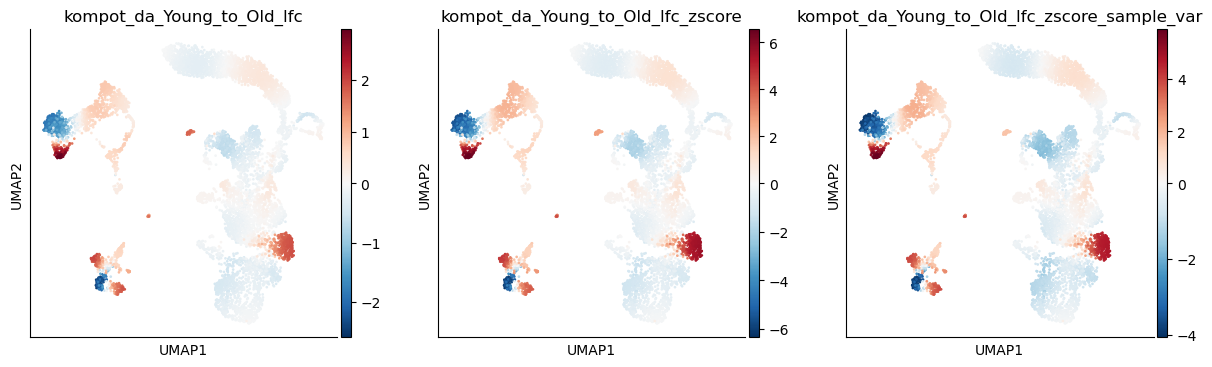

In [12]:
sc.pl.embedding(
    adata, "umap",
    color=[
        "kompot_da_Young_to_Old_lfc",
        "kompot_da_Young_to_Old_lfc_zscore",
        "kompot_da_Young_to_Old_lfc_zscore_sample_var",
    ],
    color_map="RdBu_r",
    vcenter=0,
    ncols=3,
)

Notice:
- Log fold changes (left) are identical - sample variance only affects significance
- Z-scores (middle and right) differ - sample variance produces more conservative estimates

### Volcano Plots

Compare volcano plots from both analyses:

[2025-10-03 13:42:32,069] [INFO    ] Found DA run info for run_id=0
[2025-10-03 13:42:32,070] [INFO    ] Found lfc_key='kompot_da_Young_to_Old_lfc' from run info
[2025-10-03 13:42:32,071] [INFO    ] Found ptp_key='kompot_da_Young_to_Old_neg_log10_lfc_ptp' from run info
[2025-10-03 13:42:32,072] [WARNING ] Field 'kompot_da_Young_to_Old_lfc' has been written by 2 different runs, indicating potential overwrites
[2025-10-03 13:42:32,072] [WARNING ] Field 'kompot_da_Young_to_Old_neg_log10_lfc_ptp' was last written by run 0, but current context expects run 1. The field may have been overwritten.
[2025-10-03 13:42:32,073] [INFO    ] Successfully inferred fields: {'lfc_key': 'kompot_da_Young_to_Old_lfc', 'ptp_key': 'kompot_da_Young_to_Old_neg_log10_lfc_ptp'}
[2025-10-03 13:42:32,074] [WARNING ] Field inference completed with 2 warnings
[2025-10-03 13:42:32,074] [INFO    ] Using inferred thresholds - lfc_threshold: 1.0, ptp_threshold: 0.05


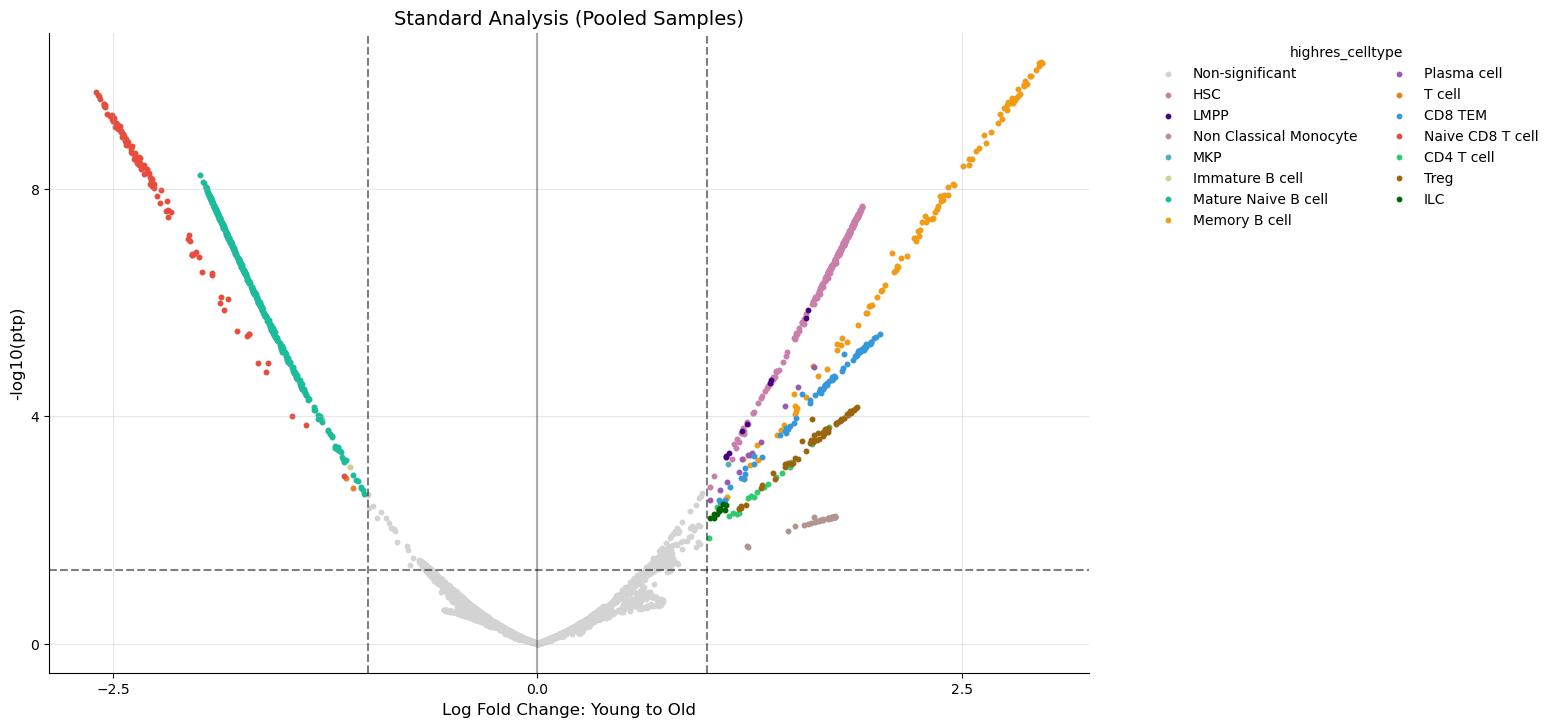

In [13]:
# Standard analysis (run_id=0)
kompot.plot.volcano_da(
    adata, 
    color=CELL_TYPE_COLUMN, 
    run_id=0,
    title="Standard Analysis (Pooled Samples)",
)

[2025-10-03 13:42:32,601] [INFO    ] Found DA run info for run_id=1
[2025-10-03 13:42:32,602] [INFO    ] Found lfc_key='kompot_da_Young_to_Old_lfc' from run info
[2025-10-03 13:42:32,602] [INFO    ] Found ptp_key='kompot_da_Young_to_Old_neg_log10_lfc_ptp_sample_var' from run info
[2025-10-03 13:42:32,602] [WARNING ] Field 'kompot_da_Young_to_Old_lfc' has been written by 2 different runs, indicating potential overwrites
[2025-10-03 13:42:32,603] [INFO    ] Successfully inferred fields: {'lfc_key': 'kompot_da_Young_to_Old_lfc', 'ptp_key': 'kompot_da_Young_to_Old_neg_log10_lfc_ptp_sample_var'}
[2025-10-03 13:42:32,603] [WARNING ] Field inference completed with 1 warnings
[2025-10-03 13:42:32,603] [INFO    ] Using inferred thresholds - lfc_threshold: 1.0, ptp_threshold: 0.1


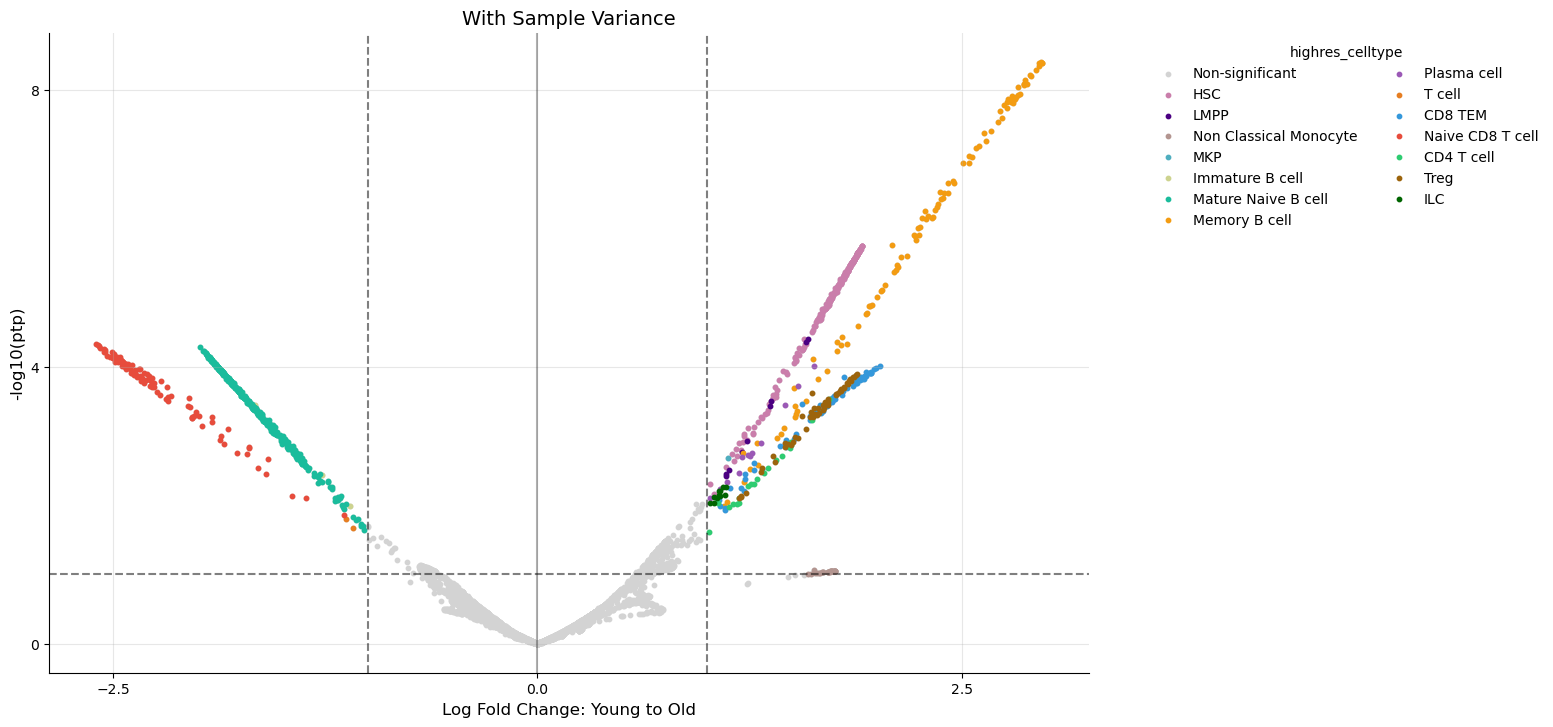

In [14]:
# With sample variance (run_id=1)
kompot.plot.volcano_da(
    adata, 
    color=CELL_TYPE_COLUMN, 
    run_id=1,
    title="With Sample Variance",
)

Note that thresholds such as `ptp_threshold` and `lfc_threshold` can be adjusted, and if `update_direction=True` is passed, then the cell-wise classification in `adata.obs["kompot_da_Young_to_Old_lfc_direction_sample_var"]` is updated accordingly.

[2025-10-03 13:42:33,119] [INFO    ] Found DA run info for run_id=1
[2025-10-03 13:42:33,120] [INFO    ] Found lfc_key='kompot_da_Young_to_Old_lfc' from run info
[2025-10-03 13:42:33,121] [INFO    ] Found ptp_key='kompot_da_Young_to_Old_neg_log10_lfc_ptp_sample_var' from run info
[2025-10-03 13:42:33,122] [WARNING ] Field 'kompot_da_Young_to_Old_lfc' has been written by 2 different runs, indicating potential overwrites
[2025-10-03 13:42:33,123] [INFO    ] Successfully inferred fields: {'lfc_key': 'kompot_da_Young_to_Old_lfc', 'ptp_key': 'kompot_da_Young_to_Old_neg_log10_lfc_ptp_sample_var'}
[2025-10-03 13:42:33,124] [WARNING ] Field inference completed with 1 warnings
[2025-10-03 13:42:33,125] [INFO    ] Updating direction column with new thresholds before plotting
[2025-10-03 13:42:33,126] [INFO    ] Found DA run info for run_id=1
[2025-10-03 13:42:33,126] [INFO    ] Found direction_key='kompot_da_Young_to_Old_lfc_direction_sample_var' from run info
[2025-10-03 13:42:33,127] [INFO    

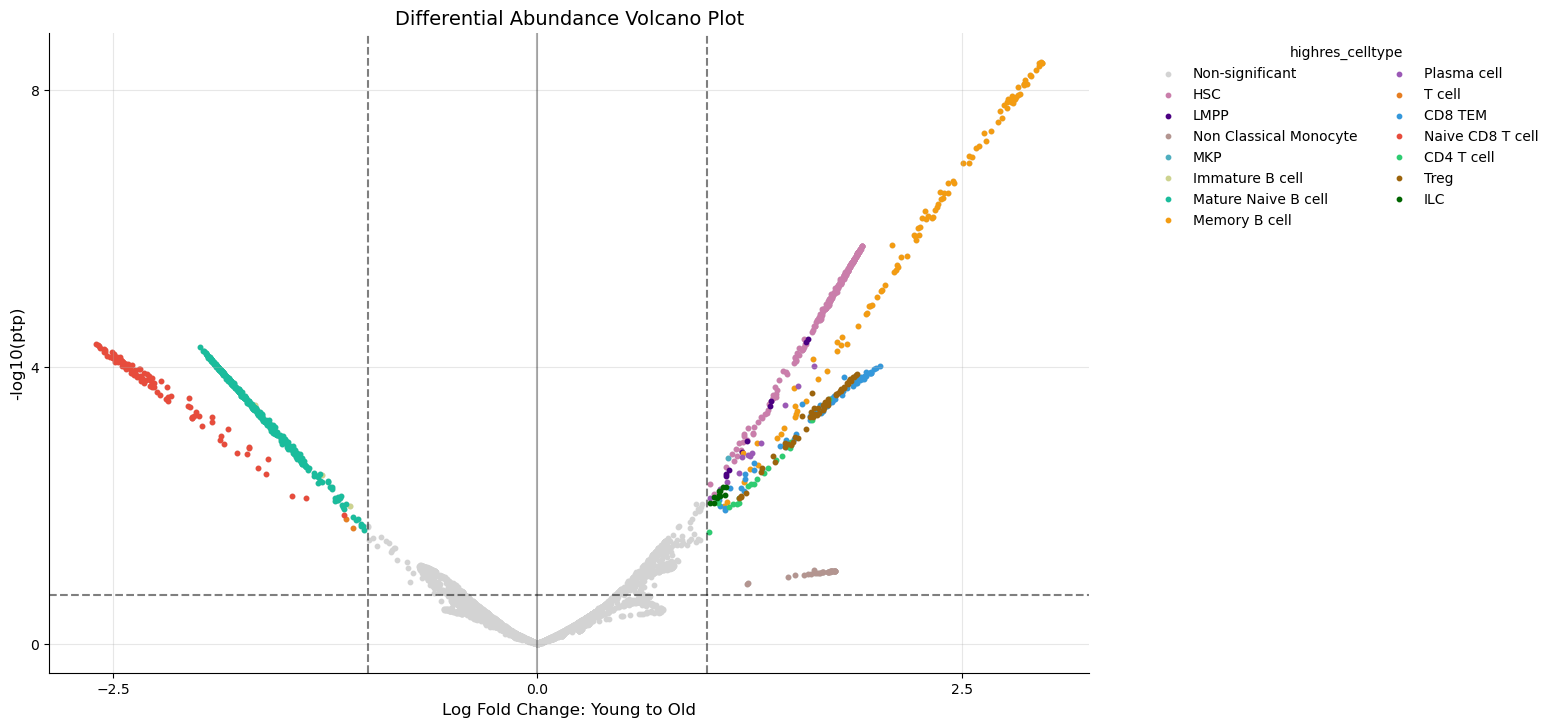

In [15]:
kompot.plot.volcano_da(adata, color=CELL_TYPE_COLUMN, run_id=1, ptp_threshold=0.2, update_direction=True)

**Key Observations:**

- Posterior tail probabilities (y-axis) are generally lower with sample variance
- Fewer cells pass significance thresholds
- Effect sizes (x-axis) remain unchanged
- Cell type patterns are preserved but with adjusted confidence

### Differential Expression

Compare Mahalanobis distances with and without sample variance:

In [16]:
# Top genes by standard analysis
comparison_df = adata.var.loc[top_genes, :][
    [
        "kompot_de_Young_to_Old_mean_lfc",
        "kompot_de_Young_to_Old_mahalanobis",
        "kompot_de_Young_to_Old_mahalanobis_sample_var",
    ]
].sort_values("kompot_de_Young_to_Old_mahalanobis", ascending=False)

comparison_df.head(20)

,kompot_de_Young_to_Old_mean_lfc,kompot_de_Young_to_Old_mahalanobis,kompot_de_Young_to_Old_mahalanobis_sample_var
H2-Q7,1.235066,71.517323,45.085446
Cd74,0.352121,60.021452,49.584290
H2-Aa,0.473756,59.371135,38.489260
H2-Ab1,0.511123,57.808982,33.768536
Igkc,0.054009,53.604112,38.973926
H2-Eb1,0.411752,53.403829,31.734637
AW112010,0.791367,53.386235,28.091721
S100a9,-0.170317,48.765184,46.502283
Ifitm3,0.367545,47.585813,40.375510
S100a8,-0.165121,47.372815,45.495007


Notice that some genes show substantially lower significance when accounting for sample variance, indicating high variability across replicates.

[2025-10-03 13:42:33,702] [INFO    ] Found DE run info for run_id=0
[2025-10-03 13:42:33,703] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Old_mean_lfc' from run info
[2025-10-03 13:42:33,704] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis' from run info
[2025-10-03 13:42:33,705] [WARNING ] Field 'kompot_de_Young_to_Old_mean_lfc' has been written by 2 different runs, indicating potential overwrites
[2025-10-03 13:42:33,705] [WARNING ] Field 'kompot_de_Young_to_Old_mahalanobis' was last written by run 0, but current context expects run 1. The field may have been overwritten.
[2025-10-03 13:42:33,706] [INFO    ] Successfully inferred fields: {'mean_lfc_key': 'kompot_de_Young_to_Old_mean_lfc', 'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis'}
[2025-10-03 13:42:33,707] [WARNING ] Field inference completed with 2 warnings
[2025-10-03 13:42:33,708] [INFO    ] Using DE run 0: comparing Young to Old
[2025-10-03 13:42:33,719] [INFO    ] Using data columns from 

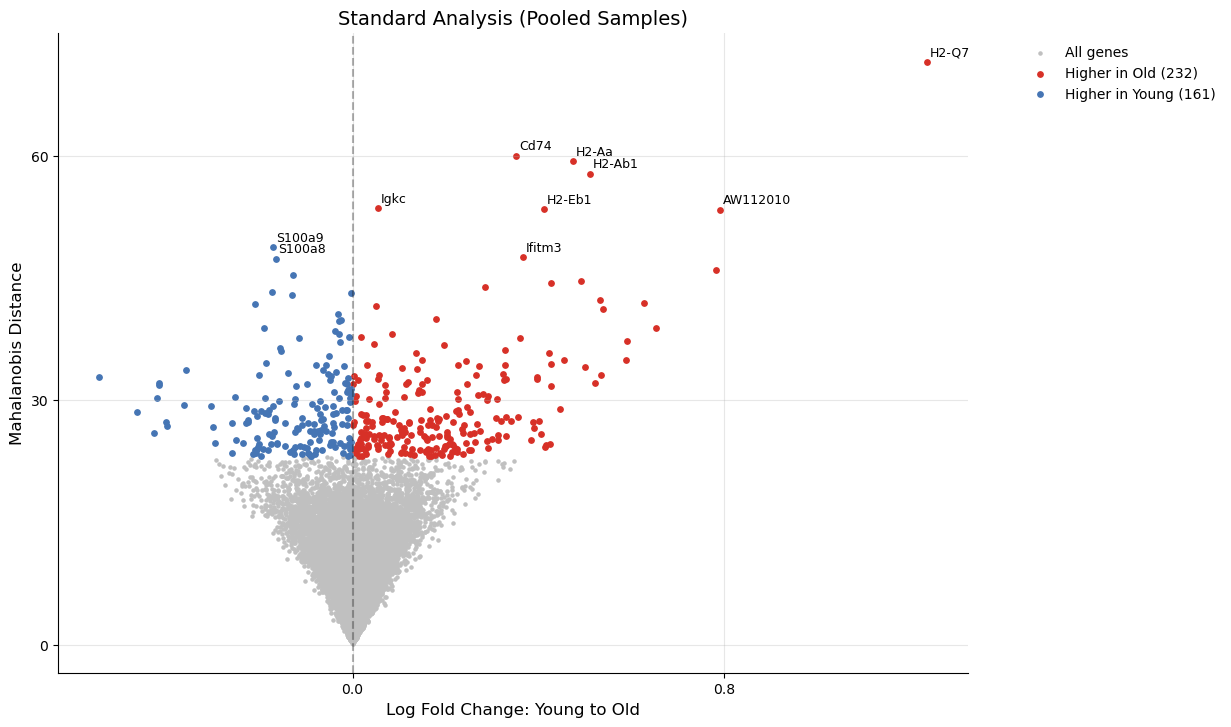

In [17]:
# Volcano plot: Standard analysis
kompot.plot.volcano_de(
    adata,
    run_id=0,
    title="Standard Analysis (Pooled Samples)",
)

[2025-10-03 13:42:33,990] [INFO    ] Found DE run info for run_id=1
[2025-10-03 13:42:33,992] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Old_mean_lfc' from run info
[2025-10-03 13:42:33,992] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis_sample_var' from run info
[2025-10-03 13:42:33,993] [WARNING ] Field 'kompot_de_Young_to_Old_mean_lfc' has been written by 2 different runs, indicating potential overwrites
[2025-10-03 13:42:33,994] [INFO    ] Successfully inferred fields: {'mean_lfc_key': 'kompot_de_Young_to_Old_mean_lfc', 'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis_sample_var'}
[2025-10-03 13:42:33,995] [WARNING ] Field inference completed with 1 warnings
[2025-10-03 13:42:33,995] [INFO    ] Using DE run 1: comparing Young to Old
[2025-10-03 13:42:34,004] [INFO    ] Using data columns from var - lfc: 'kompot_de_Young_to_Old_mean_lfc', score: 'kompot_de_Young_to_Old_mahalanobis_sample_var'
[2025-10-03 13:42:34,007] [INFO    ] Highlighting top 50

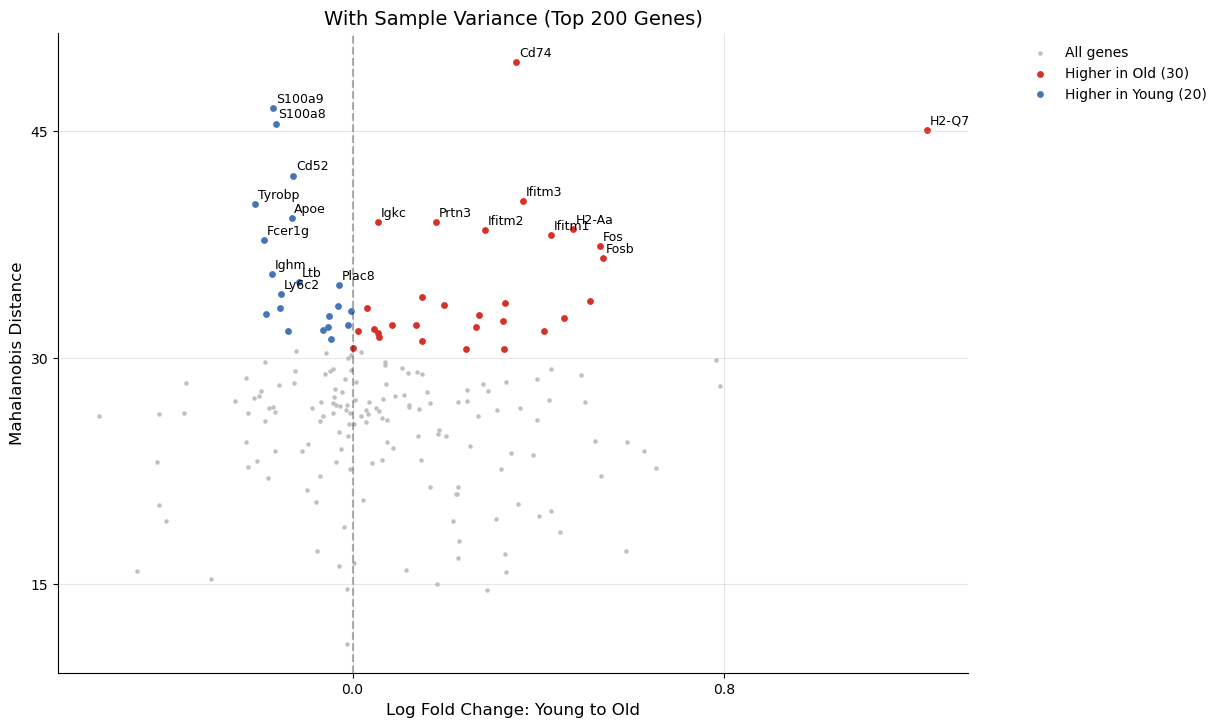

In [18]:
# Volcano plot: With sample variance
kompot.plot.volcano_de(
    adata,
    run_id=1,
    n_top_genes=50,  # No FDR threshold available (null_genes=0)
    gene_labels=20,
    title="With Sample Variance (Top 200 Genes)",
)

### Heatmaps

Visualize how ranking changes with sample variance:

[2025-10-03 13:42:34,288] [INFO    ] Found DE run info for run_id=1
[2025-10-03 13:42:34,289] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis_sample_var' from run info
[2025-10-03 13:42:34,290] [INFO    ] Successfully inferred fields: {'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis_sample_var'}
[2025-10-03 13:42:34,291] [INFO    ] Using DE run 1 for heatmap.
[2025-10-03 13:42:34,291] [INFO    ] Inferred score_key='kompot_de_Young_to_Old_mahalanobis_sample_var' from run information
[2025-10-03 13:42:34,295] [INFO    ] Inferred condition_column='Age' from run information
[2025-10-03 13:42:34,295] [INFO    ] Inferred condition1='Young' from run information
[2025-10-03 13:42:34,296] [INFO    ] Inferred condition2='Old' from run information
[2025-10-03 13:42:34,297] [INFO    ] Inferred layer='logged_counts' from run information
[2025-10-03 13:42:34,297] [INFO    ] Creating split heatmap with 20 genes/features
[2025-10-03 13:42:34,299] [INFO    ] Using expression

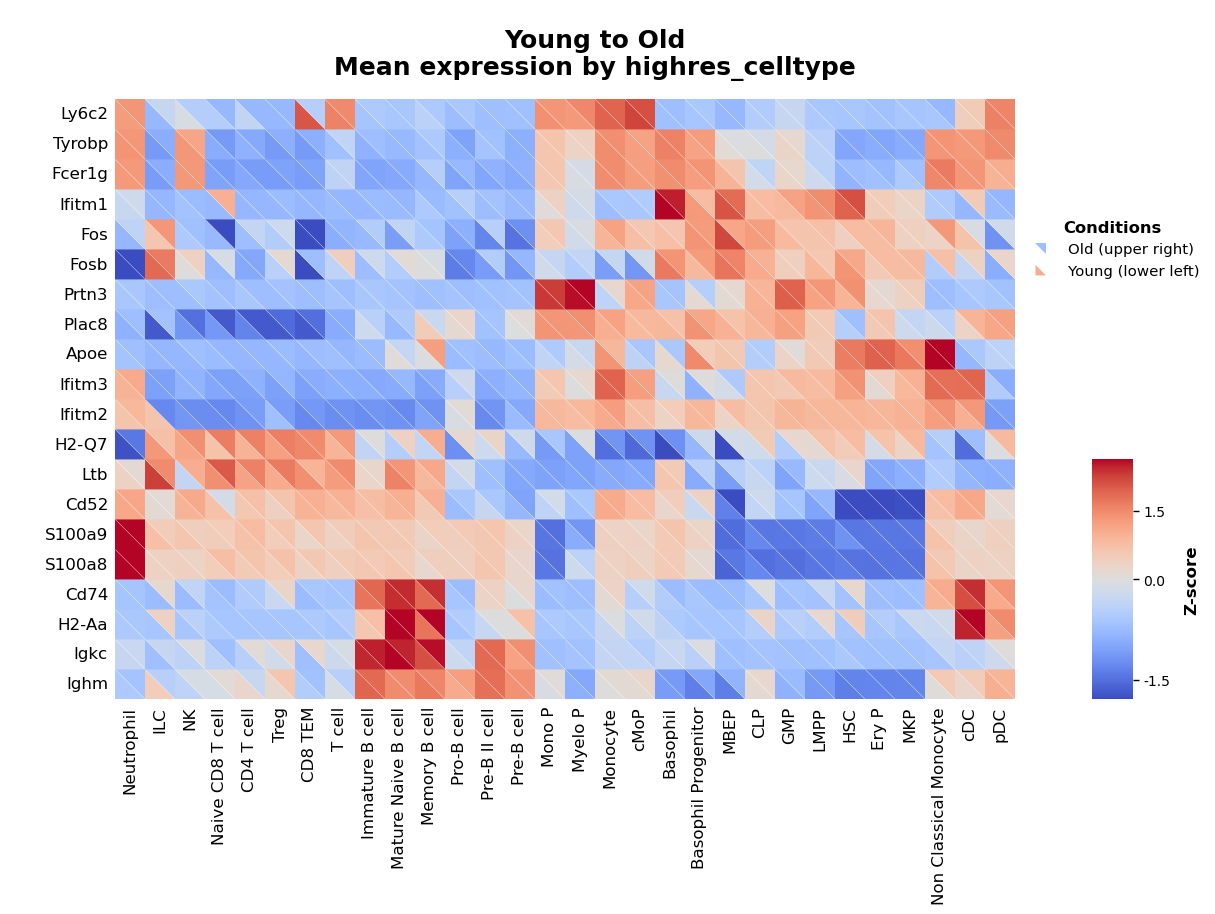

In [19]:
kompot.plot.heatmap(
    adata,
    n_top_genes=20,
    groupby=CELL_TYPE_COLUMN,
    exclude_groups="Plasma cell",
    run_id=1,  # Use sample variance ranking
    vmin="p1",
    vmax="p99",
)

## Understanding Sample-to-Sample Variability

To illustrate why sample variance matters, let's examine genes with high inter-sample variability:

In [20]:
# Genes with largest decrease in significance
comparison_df["decrease"] = (
    comparison_df["kompot_de_Young_to_Old_mahalanobis"] - 
    comparison_df["kompot_de_Young_to_Old_mahalanobis_sample_var"]
)

variable_genes = comparison_df.nlargest(20, "decrease").index
print("Genes with highest sample-to-sample variability:")
print(variable_genes.tolist())

Genes with highest sample-to-sample variability:
['H2-Q7', 'AW112010', 'H2-Ab1', 'H2-Eb1', 'H2-Aa', 'Gm47283', 'Ifi27', 'Bcl11b', 'Slc7a11', 'Gimap4', 'Trac', 'Cirbp', 'H2-Q6', 'Ccl5', 'Trbc2', 'Aldh1a1', 'Cxcl2', 'Cd3e', 'Cd3g', 'Igkc']


Compare expression between individual replicates:

[2025-10-03 13:42:35,856] [INFO    ] Inferred layer='logged_counts' from run information
[2025-10-03 13:42:35,857] [INFO    ] Creating split heatmap with 20 genes/features
[2025-10-03 13:42:35,858] [INFO    ] Using display names: 'Replicate 1' for condition1, 'Replicate 3' for condition2
[2025-10-03 13:42:35,859] [INFO    ] Using expression data from layer: 'logged_counts'
[2025-10-03 13:42:35,939] [INFO    ] Applying gene-wise z-scoring (standard_scale='var')


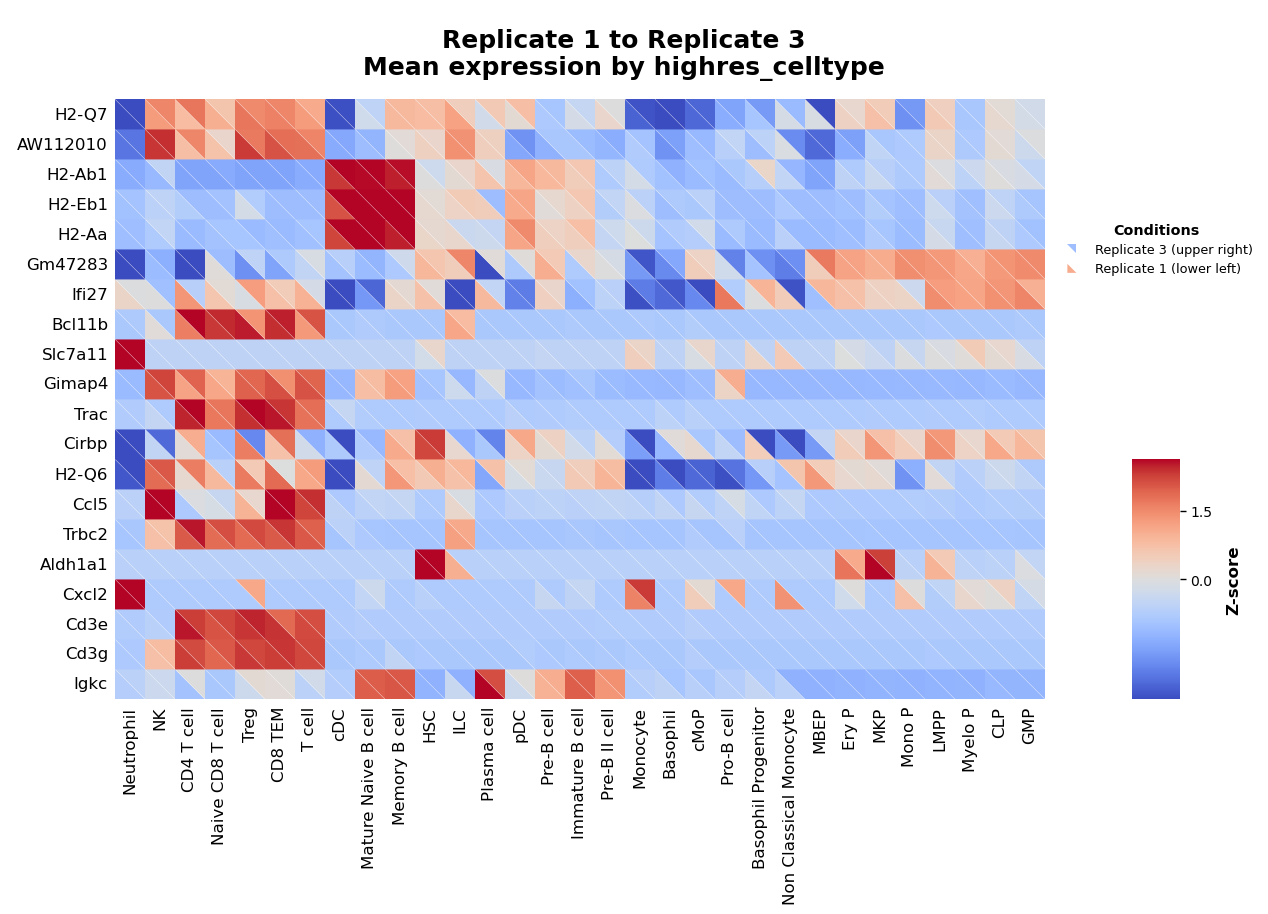

In [21]:
# Compare replicates 1 and 3
kompot.plot.heatmap(
    adata,
    genes=variable_genes,
    groupby=CELL_TYPE_COLUMN,
    condition_column=SAMPLE_COLUMN,
    condition1="1",
    condition1_name="Replicate 1",
    condition2="3",
    condition2_name="Replicate 3",
    vmin="p2",
    vmax="p98",
    cluster_rows=False,
)

These genes show substantial expression differences **between replicates of the same condition**, explaining why their significance decreases when accounting for sample variance.

## Run Tracking

Inspect metadata for both analyses:

In [30]:
# Standard analysis
run0 = kompot.RunInfo(adata, run_id=0, analysis_type="de")
run0

Parameter,Value
conditions,Young to Old
obsm_key,DM_EigenVectors
uses_sample_variance,False
layer,logged_counts
timestamp,2025-10-03T15:41:58.452419
Fields Created,9
Parameter,Value
auto_filtered,False
batch_size,0
compute_mahalanobis,True


In [24]:
# Compare runs
run0.compare_with(1)

RunComparison(run1=0, run2=1, same_fields=4, different_params=6)

## Best Practices

### When to Use Sample Variance

**Use sample variance when:**
- You have ≥3 biological replicates per condition
- You want conservative, reproducible results
- Inter-sample variability is expected (e.g., patient samples)

**Skip sample variance when:**
- Only one sample per condition
- Computational resources are limited

### Resource Considerations

Sample variance increases computation time and memory:

- **DA**: Modest increase (one estimator per sample)
- **DE**: Substantial increase (gene-specific covariances)

For DE with sample variance:
1. Always run `dry_run_differential_expression` first
2. Consider analyzing a subset of genes (top hits from standard analysis)
3. Use `store_arrays_on_disk=True` for large datasets
4. Set `null_genes=0` if you don't need FDR thresholds

### Interpretation

Results with sample variance are:
- **More conservative**: Fewer significant findings
- **More reproducible**: Robust to sample-specific effects
- **More biologically meaningful**: Account for natural variation

Genes/cell states that remain significant after sample variance correction represent robust biological signals consistent across replicates.

## Saving Results

In [25]:
# Cleanup large layers from both runs
kompot.cleanup(adata)

[2025-10-03 13:42:38,074] [INFO    ] Cleaning up all 2 run(s)
[2025-10-03 13:42:38,087] [INFO    ] Cleaned up 3 field(s) from run 0:
[2025-10-03 13:42:38,088] [INFO    ]   layers (3 field(s)):
[2025-10-03 13:42:38,088] [INFO    ]     - kompot_de_Young_imputed
[2025-10-03 13:42:38,089] [INFO    ]     - kompot_de_Old_imputed
[2025-10-03 13:42:38,090] [INFO    ]     - kompot_de_Young_to_Old_fold_change
[2025-10-03 13:42:38,092] [INFO    ] Cleaned up 2 field(s) from run 1:
[2025-10-03 13:42:38,092] [INFO    ]   layers (2 field(s)):
[2025-10-03 13:42:38,093] [INFO    ]     - kompot_de_Young_std
[2025-10-03 13:42:38,094] [INFO    ]     - kompot_de_Old_std
[2025-10-03 13:42:38,094] [INFO    ] Total: Cleaned up 5 field(s) across 2 run(s)


In [26]:
adata.write_h5ad("../data/murine_bone_marrow_aging_with_sample_variance.h5ad")

## Summary

This tutorial demonstrated:

✓ Why sample variance matters in multi-sample studies  
✓ How to enable sample variance with `sample_col` parameter  
✓ Resource planning for sample variance analyses  
✓ Comparing results with/without sample variance  
✓ Identifying sample-variable genes  
✓ Best practices for sample variance analysis  

### Key Takeaways

1. Sample variance provides **more reliable** significance estimates when you have biological replicates
2. Effect sizes remain **identical**; only statistical significance changes
3. Results are **more conservative** but also more reproducible
4. Use **resource planning** for DE with sample variance due to increased memory requirements

For more information, see the [Kompot documentation](https://kompot.readthedocs.io/en/latest/).